# Técnicas de preprocesamiento usando PyTorch
Se usará el dataset de California Housing para este ejercicio.

In [1]:
from sklearn.datasets import fetch_california_housing
x, y = fetch_california_housing(return_X_y=True, as_frame=True)
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


# Partición

In [2]:
from sklearn.model_selection import train_test_split

# 80 / 10 / 10  —  primero separamos test (10%), luego val del resto
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.20, random_state=42)
x_val,   x_test,  y_val,   y_test  = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train : {len(x_train):>5}  ({len(x_train)/len(x)*100:.0f}%)")
print(f"Val   : {len(x_val):>5}  ({len(x_val)/len(x)*100:.0f}%)")
print(f"Test  : {len(x_test):>5}  ({len(x_test)/len(x)*100:.0f}%)")

Train : 16512  (80%)
Val   :  2064  (10%)
Test  :  2064  (10%)


# Preprocesamiento

In [3]:
import torch
import torch.nn as nn

# Columnas que se procesan (todas excepto Latitude y Longitude)
COLS_TO_PROCESS = [c for c in x.columns if c not in ("Latitude", "Longitude")]
COLS_PROCESS_IDX = [list(x.columns).index(c) for c in COLS_TO_PROCESS]

class Preprocessor(nn.Module):
    def __init__(self, x_train_tensor: torch.Tensor, cols_idx: list):
        super().__init__()
        self.cols_idx = cols_idx

        data = x_train_tensor[:, cols_idx]

        # En este caso los calculo dentro de la clase
        mean = data.mean(dim=0)
        std  = data.std(dim=0)

        self.register_buffer("mean",  mean)
        self.register_buffer("std",   std)
        self.register_buffer("lower", mean - 3 * std)
        self.register_buffer("upper", mean + 3 * std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clone()
        # Clipping para quitar los outliers
        x[:, self.cols_idx] = torch.clamp(x[:, self.cols_idx], min=self.lower, max=self.upper)
        
        # Standard scaling
        x[:, self.cols_idx] = (x[:, self.cols_idx] - self.mean) / (self.std + 1e-8)
        return x

# Modelos

In [4]:
# Convertir particiones a tensores
x_train_t = torch.tensor(x_train.values, dtype=torch.float32)
x_val_t   = torch.tensor(x_val.values,   dtype=torch.float32)
x_test_t  = torch.tensor(x_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

print("Tensores creados:")
print(f"  x_train: {x_train_t.shape} | y_train: {y_train_t.shape}")
print(f"  x_val  : {x_val_t.shape}   | y_val  : {y_val_t.shape}")
print(f"  x_test : {x_test_t.shape}  | y_test : {y_test_t.shape}")

Tensores creados:
  x_train: torch.Size([16512, 8]) | y_train: torch.Size([16512, 1])
  x_val  : torch.Size([2064, 8])   | y_val  : torch.Size([2064, 1])
  x_test : torch.Size([2064, 8])  | y_test : torch.Size([2064, 1])


Creación del Housing model donde le podemos meter la lista de neuronas para cada hidden layer, el dropout y la función de activación en caso de querer cambiarla.

In [5]:
class HousingModel(nn.Module):
    def __init__(self, hidden_sizes: list[int], dropout: float = 0.0, activation=nn.ReLU):
        super().__init__()

        # Preprocesamiento. Nomás usamos el train
        self.preprocessor = Preprocessor(x_train_t, COLS_PROCESS_IDX)

        layers = []
        in_features = x_train_t.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.preprocessor(x)
        return self.network(x)

Función de entrenamiento

In [15]:
import copy
from torch.utils.data import TensorDataset, DataLoader

def train_model(model, lr: float, max_epochs: int = 150, batch_size: int = 256, patience: int = 10):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader    = DataLoader(TensorDataset(x_train_t, y_train_t),
                           batch_size=batch_size, shuffle=True)
    history   = {"train_loss": [], "val_loss": []}

    best_val        = float("inf")
    epochs_no_improve = 0
    best_weights    = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val_t), y_val_t).item()

        history["train_loss"].append(epoch_loss / len(x_train_t))
        history["val_loss"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{max_epochs} | Train MSE: {history['train_loss'][-1]:.4f} | Val MSE: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val:
            best_val          = val_loss
            best_weights      = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stop en época {epoch} (mejor Val MSE: {best_val:.4f})")
                break

    # Restaurar los pesos del mejor checkpoint
    model.load_state_dict(best_weights)
    return history

In [16]:
torch.manual_seed(42)

print("Modelo 1: [64, 32], lr=1e-3, sin dropout")
model1 = HousingModel(hidden_sizes=[64, 32], dropout=0.0)
hist1  = train_model(model1, lr=1e-3)

print("\nModelo 2: [128, 64, 32], lr=5e-4, dropout=0.2")
model2 = HousingModel(hidden_sizes=[128, 64, 32], dropout=0.2)
hist2  = train_model(model2, lr=5e-4)

print("\nModelo 3: [256, 128, 64, 32], lr=1e-3, dropout=0.3")
model3 = HousingModel(hidden_sizes=[256, 128, 64, 32], dropout=0.3)
hist3  = train_model(model3, lr=1e-3)

Modelo 1: [64, 32], lr=1e-3, sin dropout
Epoch   1/150 | Train MSE: 3.6145 | Val MSE: 1.1727
Epoch  10/150 | Train MSE: 0.6460 | Val MSE: 0.6495
Epoch  20/150 | Train MSE: 0.5268 | Val MSE: 0.5580
Epoch  30/150 | Train MSE: 0.5349 | Val MSE: 0.5544
  Early stop en época 35 (mejor Val MSE: 0.5542)

Modelo 2: [128, 64, 32], lr=5e-4, dropout=0.2
Epoch   1/150 | Train MSE: 2.2585 | Val MSE: 1.5806
Epoch  10/150 | Train MSE: 0.9596 | Val MSE: 0.9392
Epoch  20/150 | Train MSE: 0.7595 | Val MSE: 0.7597
Epoch  30/150 | Train MSE: 0.6750 | Val MSE: 0.5703
Epoch  40/150 | Train MSE: 0.6126 | Val MSE: 0.5433
Epoch  50/150 | Train MSE: 0.5736 | Val MSE: 0.5213
Epoch  60/150 | Train MSE: 0.5436 | Val MSE: 0.5089
Epoch  70/150 | Train MSE: 0.5206 | Val MSE: 0.5359
Epoch  80/150 | Train MSE: 0.5106 | Val MSE: 0.5218
  Early stop en época 86 (mejor Val MSE: 0.4741)

Modelo 3: [256, 128, 64, 32], lr=1e-3, dropout=0.3
Epoch   1/150 | Train MSE: 2.0811 | Val MSE: 1.7852
Epoch  10/150 | Train MSE: 0.8501 

Graficación de cada modelo y comparar su MSE para elegir el mejor con los datos de validación.

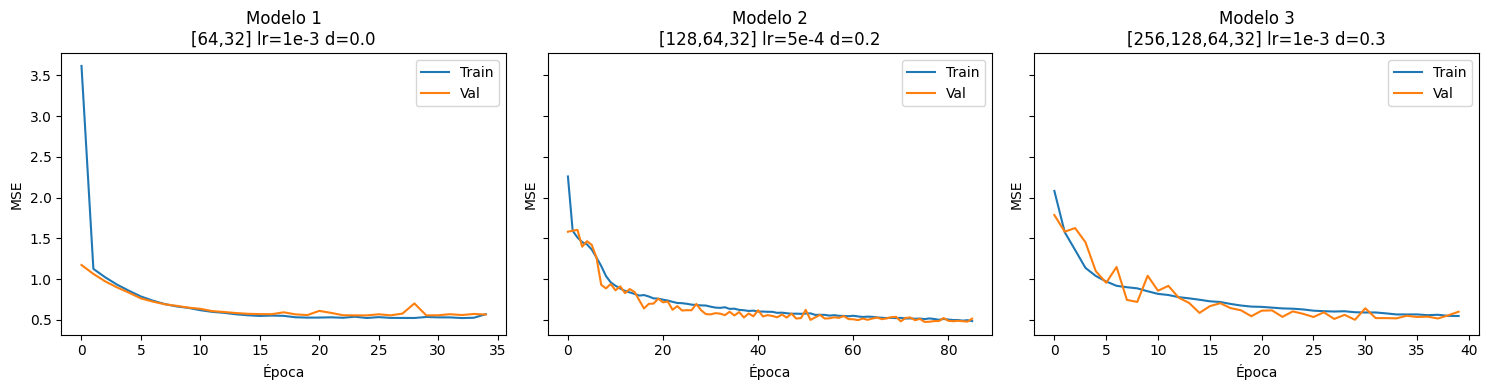

Modelo 1  →  Val MSE final: 0.5649
Modelo 2  →  Val MSE final: 0.5142
Modelo 3  →  Val MSE final: 0.5995

Mejor modelo: Modelo 2


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
configs = [
    ("Modelo 1\n[64,32] lr=1e-3 d=0.0", hist1),
    ("Modelo 2\n[128,64,32] lr=5e-4 d=0.2", hist2),
    ("Modelo 3\n[256,128,64,32] lr=1e-3 d=0.3", hist3),
]
for ax, (title, hist) in zip(axes, configs):
    ax.plot(hist["train_loss"], label="Train")
    ax.plot(hist["val_loss"],   label="Val")
    ax.set_title(title)
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE")
    ax.legend()
plt.tight_layout()
plt.show()

# Comparar MSE
final_vals = {
    "Modelo 1": hist1["val_loss"][-1],
    "Modelo 2": hist2["val_loss"][-1],
    "Modelo 3": hist3["val_loss"][-1],
}
for name, val in final_vals.items():
    print(f"{name}  →  Val MSE final: {val:.4f}")

best_name  = min(final_vals, key=final_vals.get)
best_model = {"Modelo 1": model1, "Modelo 2": model2, "Modelo 3": model3}[best_name]
print(f"\nMejor modelo: {best_name}")

A partir de los resultados, podemos ver que el modelo 2 que era la red neuronal mediana fue la que mejor performance tuvo.

De hecho, en la gráfica también se mira como la más estable y la línea naranja, que es la del MSE de validation, se mantuvo por debajo de la del train casi siempre. 

# Evaluación del mejor modelo